# Tournament Predictions

In [1]:
#setup
from rugbyModels import *
np.random.seed(1)
import warnings
warnings.filterwarnings("ignore")

data= pd.read_csv("final_data_1.csv")
data["date"] = pd.to_datetime(data["date"])


#think its reasoable to combine these for models without dgs - shouldnt overwrite like this but made the descxision too late
data["home_penalties"] = data["home_penalties"]+data["home_drop_goals"] 
data["away_penalties"] = data["away_penalties"]+data["away_drop_goals"]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [home, sd_att, sd_def, att, def_, int_try, sd_dis_clean, sd_dis_force, dis_clean, dis_force, int_pen, p_conv]


Output()

Sampling 4 chains for 1_500 tune and 2_500 draw iterations (6_000 + 10_000 draws total) took 236 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


=== Northern Hemisphere ===
          mean_pts  p_1st  p_top2  p_top3  p_top4  p_top5
France      23.639  0.591   0.813   0.923   0.983   0.998
Ireland     19.560  0.195   0.516   0.775   0.947   0.991
England     17.757  0.108   0.335   0.618   0.899   0.980
Scotland    17.536  0.102   0.315   0.598   0.887   0.977
Wales        9.724  0.004   0.016   0.061   0.188   0.636
Italy        7.674  0.001   0.005   0.025   0.096   0.418

=== Southern Hemisphere ===
              mean_pts  p_1st  p_top2  p_top3  p_top4  p_top5
South Africa    22.808  0.557   0.861   0.965   0.994   1.000
All Blacks      21.008  0.339   0.739   0.913   0.979   0.998
Argentina       15.550  0.066   0.231   0.595   0.853   0.972
Australia       13.084  0.028   0.119   0.345   0.702   0.940
Fiji             9.910  0.009   0.048   0.163   0.391   0.810
Japan            4.977  0.000   0.003   0.020   0.080   0.282


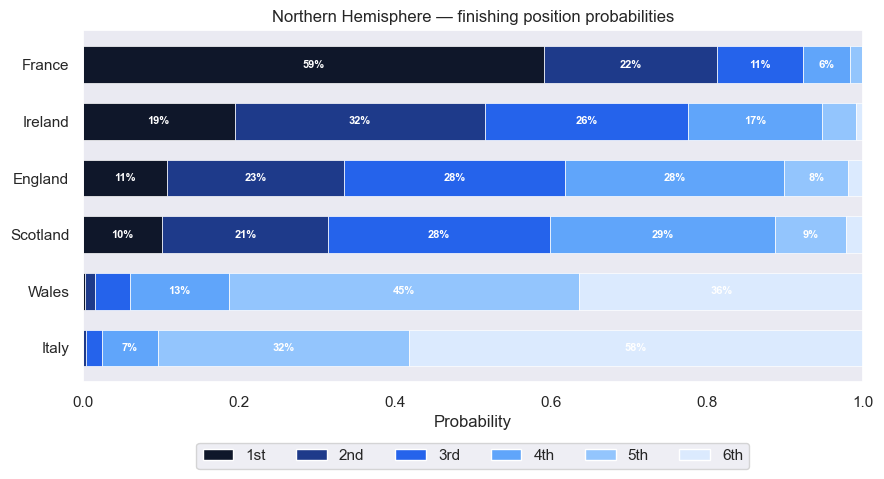

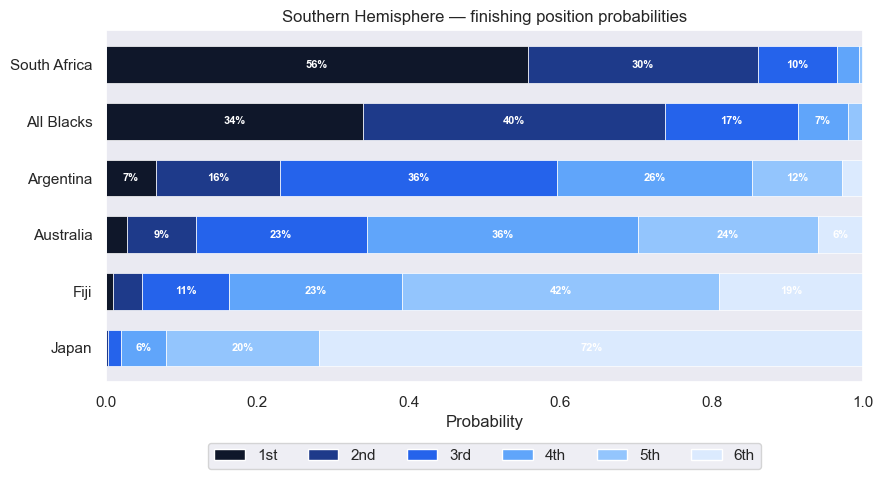

In [2]:
ncPred = PoissonModel().fit(data) # fit model
NHtable,SHtable = ncPred.simulate_group() # simulate group stage

And if we assume these group placings, how will the finals go?

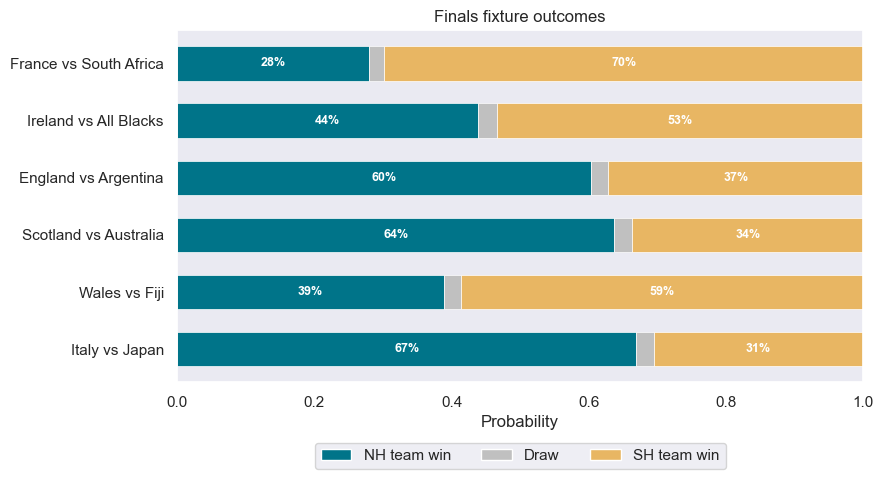

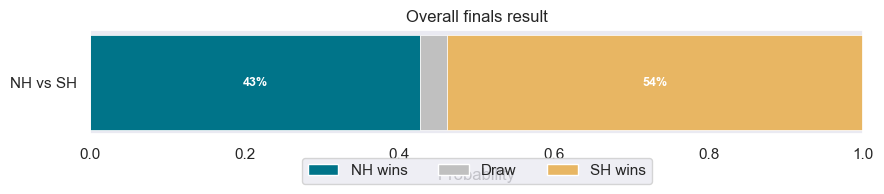

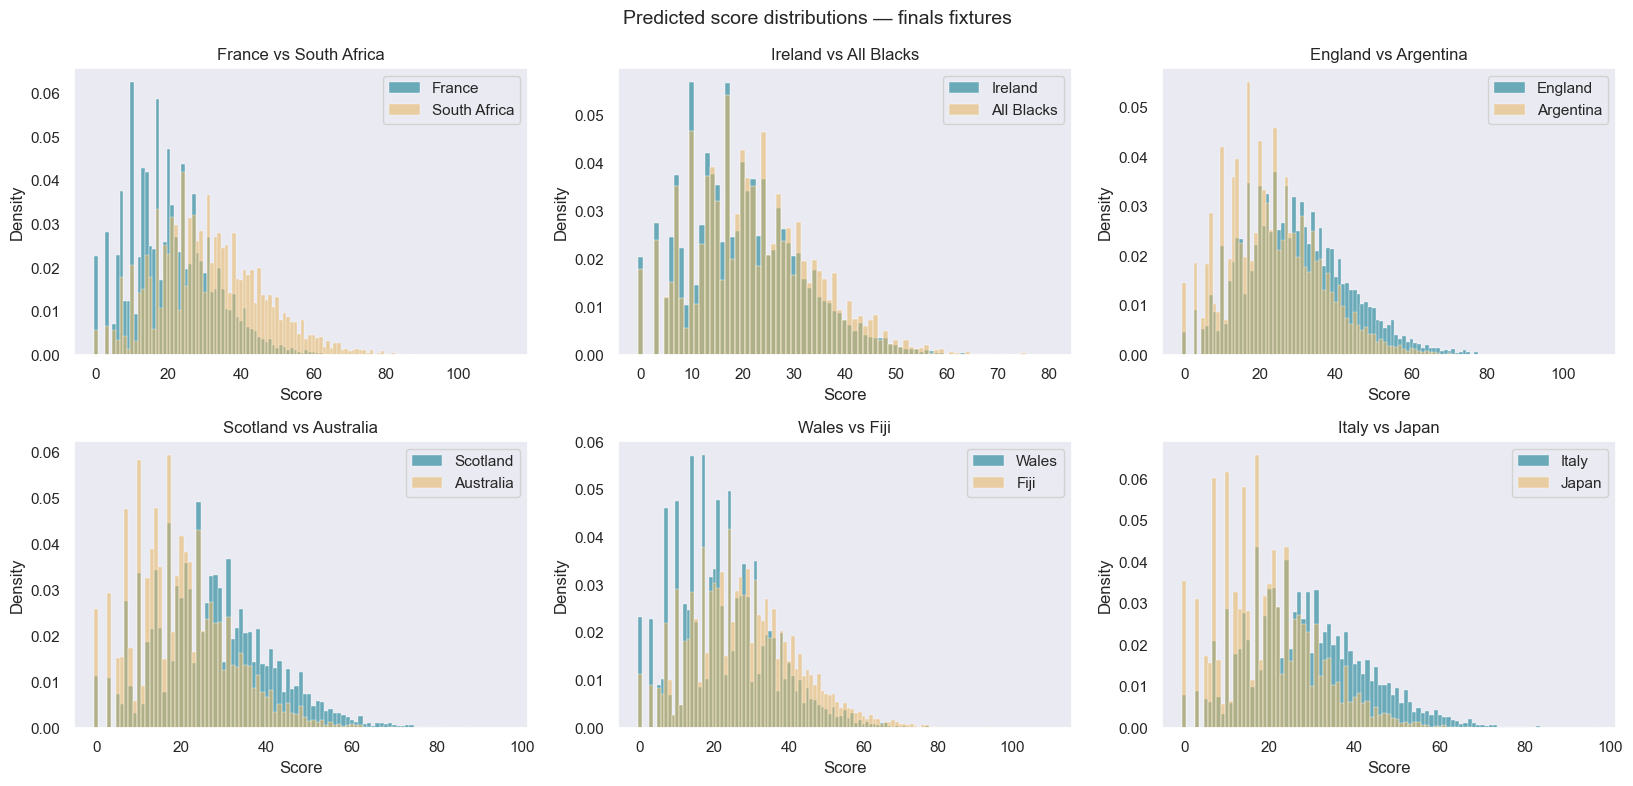

=== Finals fixtures ===
France vs South Africa: P(North)=0.280  P(Draw)=0.022  P(South)=0.698
Ireland vs All Blacks: P(North)=0.438  P(Draw)=0.027  P(South)=0.534
England vs Argentina: P(North)=0.603  P(Draw)=0.025  P(South)=0.372
Scotland vs Australia: P(North)=0.637  P(Draw)=0.026  P(South)=0.337
Wales vs Fiji: P(North)=0.388  P(Draw)=0.026  P(South)=0.586
Italy vs Japan: P(North)=0.669  P(Draw)=0.025  P(South)=0.305

Overall: P(NH wins=) = 0.426   P(Tie) = 0.036   P(SH wins=) = 0.538


In [3]:
_ = ncPred.simulate_finals(NHtable, SHtable)

And if we dont assume these placings and factor uncertainty over group stage positions into finals calculations?

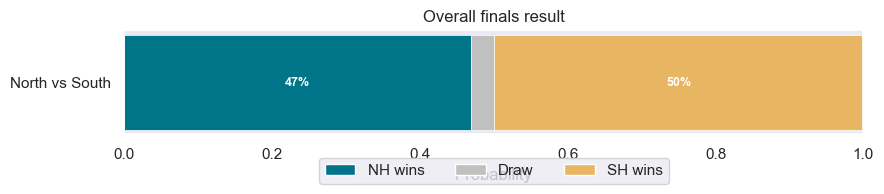

=== Finals  ===

Overall: P(North) = 0.469   P(Tie) = 0.032   P(South) = 0.500


In [4]:
_ = ncPred.simulate_finals_from_scratch()

Looking close!

----
# Pairwise win probabilitie
The probability of each team winning a home fixture against each other team.

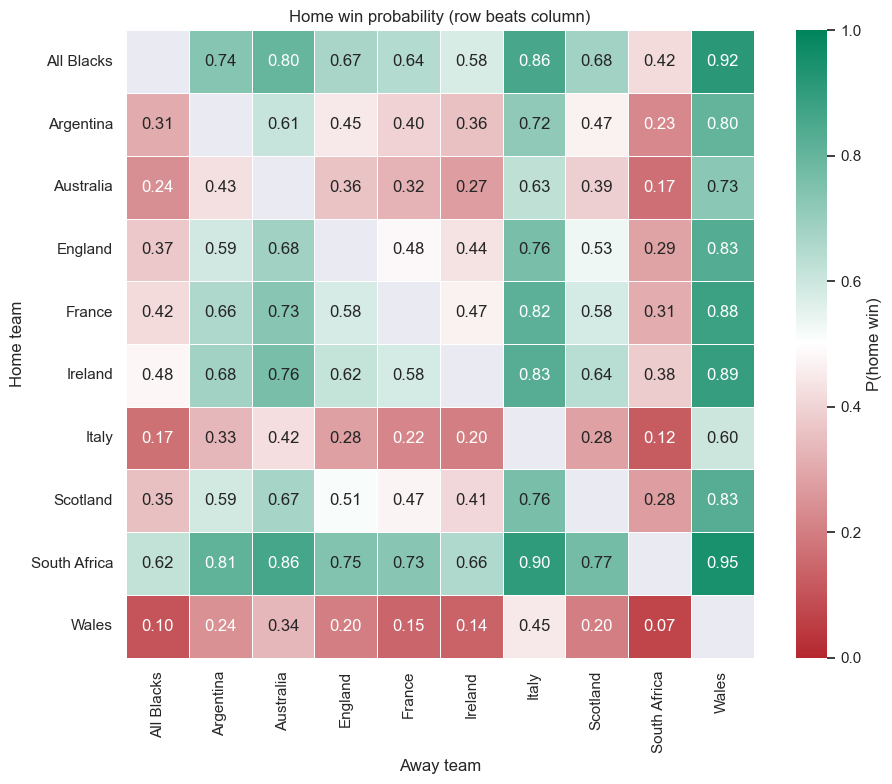

,All Blacks,Argentina,Australia,England,France,Ireland,Italy,Scotland,South Africa,Wales
All Blacks,NaN,0.7364,0.8007,0.6687,0.6449,0.5760,0.8576,0.6818,0.4173,0.9179
Argentina,0.3080,NaN,0.6132,0.4463,0.3984,0.3580,0.7187,0.4651,0.2265,0.8046
Australia,0.2404,0.4295,NaN,0.3626,0.3208,0.2746,0.6282,0.3886,0.1653,0.7269
England,0.3745,0.5929,0.6836,NaN,0.4835,0.4358,0.7637,0.5346,0.2857,0.8336
France,0.4155,0.6565,0.7341,0.5789,NaN,0.4679,0.8174,0.5829,0.3110,0.8825
Ireland,0.4800,0.6805,0.7619,0.6161,0.5821,NaN,0.8286,0.6402,0.3797,0.8914
Italy,0.1708,0.3327,0.4237,0.2801,0.2189,0.2030,NaN,0.2832,0.1175,0.5988
Scotland,0.3523,0.5872,0.6728,0.5148,0.4735,0.4089,0.7638,NaN,0.2764,0.8303
South Africa,0.6180,0.8110,0.8605,0.7458,0.7323,0.6562,0.9044,0.7696,NaN,0.9473
Wales,0.1045,0.2448,0.3351,0.2013,0.1473,0.1373,0.4463,0.2016,0.0686,NaN


In [5]:
ncPred.plot_pairwise_win_probs()

----
# Interpretability
What is driving each teams success/failure?

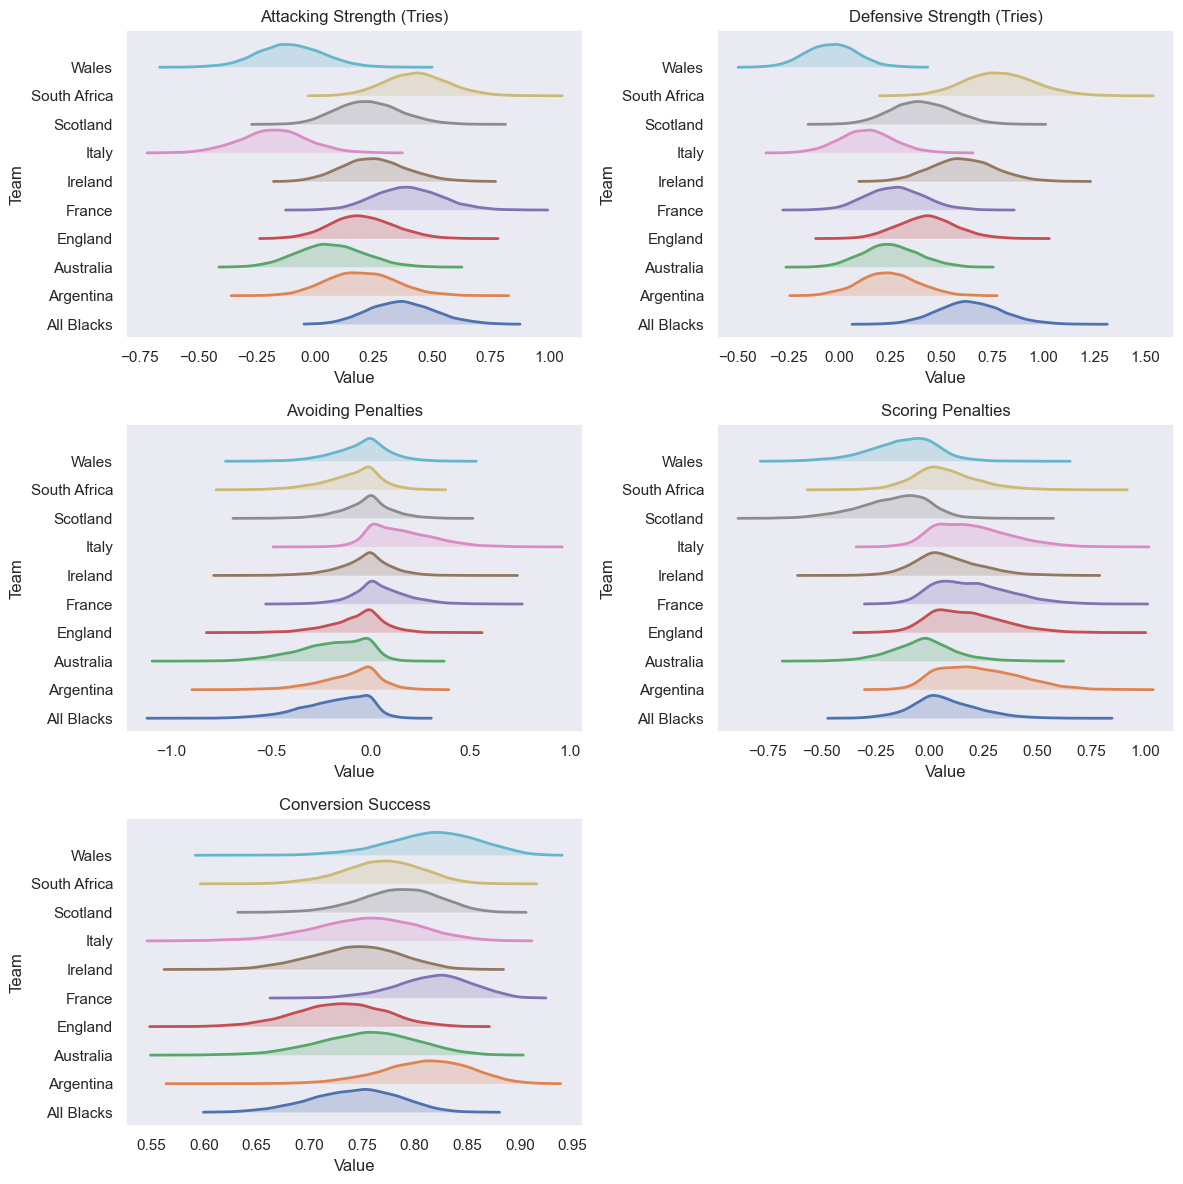

In [6]:
ncPred.plot_params()